In [1]:
import os
import copy
import logging
import h5py as h5
import numpy as np
import pandas as pd
import astropy.units as u
import matplotlib.pyplot as plt
import matplotlib

import matplotlib.cm as cm



# ------------------------------
# Plot style
# ------------------------------
matplotlib.rcParams.update({
    'font.size': 20,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.major.size': 6,
    'ytick.minor.size': 3,
    'xtick.major.width': 1,
    'ytick.major.width': 1,
    'xtick.minor.width': 0.8,
    'ytick.minor.width': 0.8,
    'xtick.top': True,
    'ytick.right': True,
    'xtick.bottom': True,
    'ytick.left': True,
    
    'text.usetex': True,  # Enable LaTeX rendering
    'font.family': 'serif',
    'font.serif': ['Computer Modern'],  # LaTeX default font
})

Zsun = 0.02  
threshold = 1.00 #threshold for MRR, mB > threshold * mA
# ------------------------------
# Load COMPAS data
# ------------------------------

with h5.File("processed_yields_COMPAS.h5", "r") as f:
    z_vals_compas = f["z_values"][()]
    Y_compas      = f["yields"][()]

    # LVK defined M1
    m1_compas     = np.maximum(f["event_properties/mass_1"][()],
                                f["event_properties/mass_2"][()])
    m2_compas     = np.minimum(f["event_properties/mass_1"][()],
                                f["event_properties/mass_2"][()])
    
    MRR_bh_compas = (f["event_properties/mass_2"][()] > threshold *
                     f["event_properties/mass_1"][()])

    Z_compas      = f["event_properties/metallicity"][()]  
    logZrel_compas  = np.log10(Z_compas / Zsun)

    # Just ensure we are grabbing M1 and M2 ZAMS. 
    zams1_compas  = np.maximum(f["event_properties/zams_mass_1"][()],
                                f["event_properties/zams_mass_2"][()])
    zams2_compas  = np.minimum(f["event_properties/zams_mass_1"][()],
                                f["event_properties/zams_mass_2"][()])
    
    delay_time_compas = f["event_properties/delay_time_in_years"][()]  

    # MASSquerade

    m1_compas_binary_assumption = f["event_properties/mass_1"][()]
    m2_compas_binary_assumption = f["event_properties/mass_2"][()]

# ------------------------------
# Load SEVN data
# ------------------------------

# with h5.File("processed_yields_SEVN.h5", "r") as f:
with h5.File("../data/yields/sevn_updated.hdf5", "r") as f:
    z_vals_sevn = f["z_values"][()]
    Y_sevn      = f["yields"][()]

    m1_sevn     = np.maximum(f["event_properties/mass_1"][()],
                              f["event_properties/mass_2"][()])
    m2_sevn     = np.minimum(f["event_properties/mass_1"][()],
                              f["event_properties/mass_2"][()])
    MRR_bh_sevn = (f["event_properties/mass_2"][()] > threshold *
                   f["event_properties/mass_1"][()])

    Z_sevn      = f["event_properties/metallicity"][()]
    logZrel_sevn  = np.log10(Z_sevn / Zsun)

    zams1_sevn  = np.maximum(f["event_properties/zams_mass_1"][()],
                              f["event_properties/zams_mass_2"][()])
    zams2_sevn  = np.minimum(f["event_properties/zams_mass_1"][()],
                                f["event_properties/zams_mass_2"][()])

    delay_time_sevn = f["event_properties/delay_time_in_years"][()]  

    # MASSquerade

    m1_sevn_binary_assumption = f["event_properties/mass_1"][()]
    m2_sevn_binary_assumption = f["event_properties/mass_2"][()]


# Fig 5

In [2]:

import string
DCOtype = 'BBH'  

path = '../sims/fiducial_compas/fiducial/COMPASCompactOutput_'+ DCOtype +'_A.h5' # fiducial 

fdata = h5.File(path)

dco = fdata['doubleCompactObjects']
df = pd.DataFrame({
    'Massrem_0': dco['M1'][...].squeeze(),
    'Massrem_1': dco['M2'][...].squeeze(),
    'Mass_0': dco['M1ZAMS'][...].squeeze(),
    'Mass_1': dco['M2ZAMS'][...].squeeze(),
    'Metallicity': dco['Metallicity1'][...].squeeze(),
    'MergerTime': dco['tc'][...].squeeze(),
    'Eccentricity' : dco['eccentricityInitial'][...].squeeze(),
    'Semimajor' : dco['separationInitial'][...].squeeze(),
    'Weight' : dco['weight'][...].squeeze()
    #'tform': dco['tform'][...].squeeze(),
    #'weight': dco['weight'][...].squeeze(),
    #'mergesInHubble': dco['mergesInHubbleTimeFlag'][...].squeeze()
})


df['PrimaryMass_BH'] = np.maximum(df['Massrem_0'], df['Massrem_1'])
df['SecondaryMass_BH'] = np.minimum(df['Massrem_0'], df['Massrem_1'])

df['PrimaryZAMS'] = np.where(
    df['Massrem_0'] >= df['Massrem_1'],
    df['Mass_0'],
    df['Mass_1']
)

df['SecondaryZAMS'] = np.where(
    df['Massrem_0'] < df['Massrem_1'],
    df['Mass_0'],
    df['Mass_1']
)

df['Mchirp'] = (
    (df['PrimaryMass_BH'] * df['SecondaryMass_BH'])**(3/5)
    / (df['PrimaryMass_BH'] + df['SecondaryMass_BH'])**(1/5)
)


df['MRR'] = (df['Mass_0'] > df['Mass_1']) & (df['Massrem_0'] < df['Massrem_1'])

df_COMPAS=df

In [4]:
df_SEVN = pd.read_hdf("../sims/master_bbh.h5", key="bbh")

#Rename columns
df_SEVN = df_SEVN.rename(columns={
    "ZAMS_M0":     "zams_mass_1",
    "ZAMS_M1":     "zams_mass_2",
    "Massrem_0":   "mass_1",
    "Massrem_1":   "mass_2",
    "Metallicity":  "metallicity",
    "ZAMS_ecc":    "eccentricity",
    "MergerTime":  "MergerTime",   # keep as is, derive below
})


df_SEVN["delay_time_in_years"]        = df_SEVN["MergerTime"] * 1e6
df_SEVN["delay_time_values_in_years"] = df_SEVN["delay_time_in_years"]

# IMF
alpha = -2.3
m_min, m_max = 3, 200
norm = (m_max**(alpha + 1) - m_min**(alpha + 1)) / (alpha + 1)
df_SEVN["Weight_norm"] = 197 * (df_SEVN["zams_mass_1"] ** alpha) / norm


df_SEVN["MRR"] = df_SEVN["mass_2"] > df_SEVN["mass_1"]


In [5]:
qzams_compas   = zams2_compas / zams1_compas
qbh_compas     = m2_compas    / m1_compas
qzams_sevn     = zams2_sevn   / zams1_sevn
qbh_sevn       = m2_sevn      / m1_sevn

# weights
z_idx    =2
w_compas = Y_compas[z_idx] #1
w_sevn   = Y_sevn[z_idx] #1

# bins
Z_bins_COMPAS = np.linspace(-2.5, 0, 12)
Z_bins_SEVN   = np.linspace(-4.0, 0, 16)

M1z_bins  = np.arange(10, 203, 3)
BH1_bins  = np.arange(3,  53,  3)
M2z_bins  = np.arange(10,  203, 3)
BH2_bins  = np.arange(3,  53,  3)
q_bins    = np.linspace(0, 1, 25)      # q always 0→1


def compute_mrr_map(x, logZrel, weights, mrr_flag, xbins, zbins):
    if np.isscalar(weights):
        weights = np.ones(len(x))
    H_mrr, _, _ = np.histogram2d(
        x, logZrel, bins=[xbins, zbins],
        weights=weights * mrr_flag.astype(float)
    )
    H_tot, _, _ = np.histogram2d(
        x, logZrel, bins=[xbins, zbins],
        weights=weights
    )
    return np.divide(
        H_mrr, H_tot,
        out=np.zeros_like(H_mrr),
        where=H_tot > 0
    ).T


# --- M1 ---
map_C_M1z  = compute_mrr_map(zams1_compas, logZrel_compas, w_compas, MRR_bh_compas, M1z_bins, Z_bins_COMPAS)
map_C_M1bh = compute_mrr_map(m1_compas,    logZrel_compas, w_compas, MRR_bh_compas, BH1_bins, Z_bins_COMPAS)
map_S_M1z  = compute_mrr_map(zams1_sevn,   logZrel_sevn,   w_sevn,   MRR_bh_sevn,   M1z_bins, Z_bins_SEVN)
map_S_M1bh = compute_mrr_map(m1_sevn,      logZrel_sevn,   w_sevn,   MRR_bh_sevn,   BH1_bins, Z_bins_SEVN)

# # --- M2 ---
map_C_M2z  = compute_mrr_map(zams2_compas, logZrel_compas, w_compas, MRR_bh_compas, M2z_bins, Z_bins_COMPAS)
map_C_M2bh = compute_mrr_map(m2_compas,    logZrel_compas, w_compas, MRR_bh_compas, BH2_bins, Z_bins_COMPAS)
map_S_M2z  = compute_mrr_map(zams2_sevn,   logZrel_sevn,   w_sevn,   MRR_bh_sevn,   M2z_bins, Z_bins_SEVN)
map_S_M2bh = compute_mrr_map(m2_sevn,      logZrel_sevn,   w_sevn,   MRR_bh_sevn,   BH2_bins, Z_bins_SEVN)

# # --- q ---
map_C_qz   = compute_mrr_map(qzams_compas, logZrel_compas, w_compas, MRR_bh_compas, q_bins,   Z_bins_COMPAS)
map_C_qbh  = compute_mrr_map(qbh_compas,   logZrel_compas, w_compas, MRR_bh_compas, q_bins,   Z_bins_COMPAS)
map_S_qz   = compute_mrr_map(qzams_sevn,   logZrel_sevn,   w_sevn,   MRR_bh_sevn,   q_bins,   Z_bins_SEVN)
map_S_qbh  = compute_mrr_map(qbh_sevn,     logZrel_sevn,   w_sevn,   MRR_bh_sevn,   q_bins,   Z_bins_SEVN)


### now using zams definition for m1 bh

# map_C_M1z  = compute_mrr_map(zams1_compas, logZrel_compas, w_compas, MRR_bh_compas, M1z_bins, Z_bins_COMPAS)
# map_C_M1bh = compute_mrr_map(m1_compas_binary_assumption,    logZrel_compas, w_compas, MRR_bh_compas, BH1_bins, Z_bins_COMPAS)
# map_S_M1z  = compute_mrr_map(zams1_sevn,   logZrel_sevn,   w_sevn,   MRR_bh_sevn,   M1z_bins, Z_bins_SEVN)
# map_S_M1bh = compute_mrr_map(m1_sevn_binary_assumption,      logZrel_sevn,   w_sevn,   MRR_bh_sevn,   BH1_bins, Z_bins_SEVN)

# # --- M2 ---
# map_C_M2z  = compute_mrr_map(zams2_compas, logZrel_compas, w_compas, MRR_bh_compas, M2z_bins, Z_bins_COMPAS)
# map_C_M2bh = compute_mrr_map(m2_compas_binary_assumption,    logZrel_compas, w_compas, MRR_bh_compas, BH2_bins, Z_bins_COMPAS)
# map_S_M2z  = compute_mrr_map(zams2_sevn,   logZrel_sevn,   w_sevn,   MRR_bh_sevn,   M2z_bins, Z_bins_SEVN)
# map_S_M2bh = compute_mrr_map(m2_sevn_binary_assumption,      logZrel_sevn,   w_sevn,   MRR_bh_sevn,   BH2_bins, Z_bins_SEVN)

# # # --- q ---
# map_C_qz   = compute_mrr_map(qzams_compas, logZrel_compas, w_compas, MRR_bh_compas, q_bins,   Z_bins_COMPAS)
# map_C_qbh  = compute_mrr_map(qbh_compas,   logZrel_compas, w_compas, MRR_bh_compas, q_bins,   Z_bins_COMPAS)
# map_S_qz   = compute_mrr_map(qzams_sevn,   logZrel_sevn,   w_sevn,   MRR_bh_sevn,   q_bins,   Z_bins_SEVN)
# map_S_qbh  = compute_mrr_map(qbh_sevn,     logZrel_sevn,   w_sevn,   MRR_bh_sevn,   q_bins,   Z_bins_SEVN)



/var/folders/2l/_z2r_pxd24s141g1v74njc480000gn/T/ipykernel_20351/3806343267.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


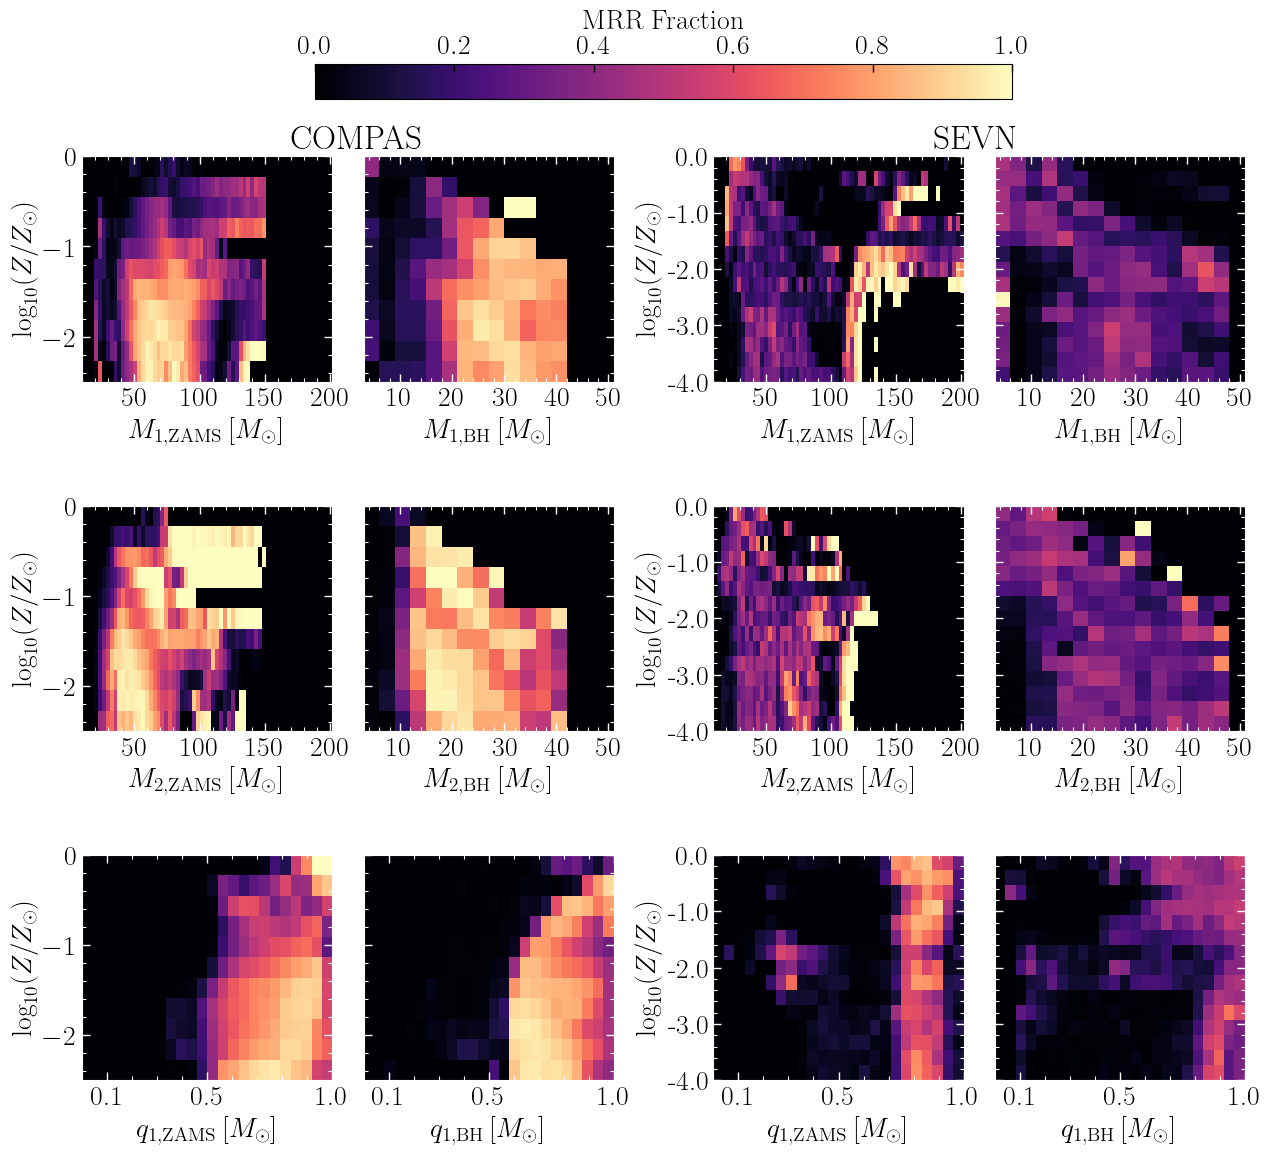

In [6]:
from matplotlib.ticker import FormatStrFormatter
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(15, 15))
gs = gridspec.GridSpec(
    3, 5,
    width_ratios=[1, 1, 0.15, 1, 1],  # middle gap
    wspace=0.15,
    hspace=0.55
)

axes = np.empty((3,4), dtype=object)

# Left block (COMPAS)
for i in range(3):
    axes[i,0] = fig.add_subplot(gs[i,0])
    axes[i,1] = fig.add_subplot(gs[i,1])

# Right block (SEVN)
for i in range(3):
    axes[i,2] = fig.add_subplot(gs[i,3])
    axes[i,3] = fig.add_subplot(gs[i,4])
    

cmap = "magma"
vmin, vmax = 0.0, 1.0

def pmesh(ax, xbins, zbins, data):
    return ax.pcolormesh(xbins, zbins, data,
                         cmap=cmap, vmin=vmin, vmax=vmax,
                         shading="auto", linewidth=0, edgecolors='face')

# --- Row 0: M1 ---
im00 = pmesh(axes[0, 0], M1z_bins,  Z_bins_COMPAS, map_C_M1z)
im01 = pmesh(axes[0, 1], BH1_bins,  Z_bins_COMPAS, map_C_M1bh)
im02 = pmesh(axes[0, 2], M1z_bins,  Z_bins_SEVN,   map_S_M1z)
im03 = pmesh(axes[0, 3], BH1_bins,  Z_bins_SEVN,   map_S_M1bh)

# --- Row 1: M2 ---
im10 = pmesh(axes[1, 0], M2z_bins,  Z_bins_COMPAS, map_C_M2z)
im11 = pmesh(axes[1, 1], BH2_bins,  Z_bins_COMPAS, map_C_M2bh)
im12 = pmesh(axes[1, 2], M2z_bins,  Z_bins_SEVN,   map_S_M2z)
im13 = pmesh(axes[1, 3], BH2_bins,  Z_bins_SEVN,   map_S_M2bh)

# --- Row 2: q ---
im20 = pmesh(axes[2, 0], q_bins,    Z_bins_COMPAS, map_C_qz)
im21 = pmesh(axes[2, 1], q_bins,    Z_bins_COMPAS, map_C_qbh)
im22 = pmesh(axes[2, 2], q_bins,    Z_bins_SEVN,   map_S_qz)
im23 = pmesh(axes[2, 3], q_bins,    Z_bins_SEVN,   map_S_qbh)

# Column titles (top row only) 
axes[0, 0].set_title(r"COMPAS",x=1.1)#, fontsize=13)
axes[0, 1].set_title(r" ")
axes[0, 2].set_title(r"SEVN",x=1.05)
axes[0, 3].set_title(r" ")#,     fontsize=13)

# y-labels (left column only) 
axes[0, 0].set_ylabel(r"$\log_{10}(Z/Z_\odot)$")#, fontsize=12)
axes[1, 0].set_ylabel(r"$\log_{10}(Z/Z_\odot)$")#, fontsize=12)
axes[2, 0].set_ylabel(r"$\log_{10}(Z/Z_\odot)$")#, fontsize=12)
#axes[3, 0].set_ylabel(r"$\log_{10}(Z/Z_\odot)$")#, fontsize=12)

axes[0, 2].set_ylabel(r"$\log_{10}(Z/Z_\odot)$")#, fontsize=12)
axes[1, 2].set_ylabel(r"$\log_{10}(Z/Z_\odot)$")#, fontsize=12)
axes[2, 2].set_ylabel(r"$\log_{10}(Z/Z_\odot)$")#, fontsize=12)

# x-labels (bottom row only)
axes[2, 0].set_xlabel(r"$q_{1,\mathrm{ZAMS}}\,[M_\odot]$")#, fontsize=12)
axes[2, 1].set_xlabel(r"$q_{1,\mathrm{BH}}\,[M_\odot]$")#,   fontsize=12)
axes[2, 2].set_xlabel(r"$q_{1,\mathrm{ZAMS}}\,[M_\odot]$")#, fontsize=12)
axes[2, 3].set_xlabel(r"$q_{1,\mathrm{BH}}\,[M_\odot]$")#,   fontsize=12)

axes[1, 0].set_xlabel(r"$M_{2,\mathrm{ZAMS}}\,[M_\odot]$")#, fontsize=12)
axes[1, 1].set_xlabel(r"$M_{2,\mathrm{BH}}\,[M_\odot]$")#,   fontsize=12)
axes[1, 2].set_xlabel(r"$M_{2,\mathrm{ZAMS}}\,[M_\odot]$")#, fontsize=12)
axes[1, 3].set_xlabel(r"$M_{2,\mathrm{BH}}\,[M_\odot]$")#,   fontsize=12)

axes[0, 0].set_xlabel(r"$M_{1,\mathrm{ZAMS}}\,[M_\odot]$")#, fontsize=12)
axes[0, 1].set_xlabel(r"$M_{1,\mathrm{BH}}\,[M_\odot]$")#,   fontsize=12)
axes[0, 2].set_xlabel(r"$M_{1,\mathrm{ZAMS}}\,[M_\odot]$")#, fontsize=12)
axes[0, 3].set_xlabel(r"$M_{1,\mathrm{BH}}\,[M_\odot]$")#,   fontsize=12)


for ax in axes[:, [1, 3]].ravel():
    ax.tick_params(labelleft=False)

for ax in axes[:, 2:].ravel():
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

# --- Rasterize + white ticks ---
all_ims = [im00, im01, im02, im03,
           im10, im11, im12, im13,
           im20, im21, im22, im23]

for im in all_ims:
    im.set_rasterized(True)

for ax in axes.ravel():
    ax.minorticks_on()
    ax.tick_params(which='both', color='white', labelcolor='k')
    for spine in ax.spines.values():
        spine.set_edgecolor('white')
    ax.xaxis.label.set_color('k')
    ax.yaxis.label.set_color('k')


for ax in axes[2, :]:
    ax.set_xticks([0.1,0.5,  1.0])
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))

for ax in axes[1, [0, 2]]:  # ZAMS 
    ax.set_xticks([50,100,150,200])  


for ax in axes[0, [0, 2]]:  # ZAMS 
    ax.set_xticks([50,100,150,200])  


for ax in axes[1, [0, 2]]:  # ZAMS 
    ax.set_xticks([50,100,150,200])  


for ax in axes[0, [1, 3]]:  # BH
    ax.set_xticks([10,20, 30,40, 50])  

for ax in axes[1, [1, 3]]:  # BH
    ax.set_xticks([10,20, 30,40, 50])  
    
cbar = fig.colorbar(
    im23, ax=axes.ravel().tolist(),
    shrink=0.6, pad=0.05, location="top"
)
cbar.set_label("MRR Fraction")#, fontsize=14)

plt.tight_layout()
plt.savefig("../plots/final-mrr_3x4_compas_v_sevn.pdf", bbox_inches="tight", pad_inches=0.04)
plt.show()

# Fig 16

In [7]:

map_C_M1z  = compute_mrr_map(zams1_compas, logZrel_compas, w_compas, MRR_bh_compas, M1z_bins, Z_bins_COMPAS)
map_C_M1bh = compute_mrr_map(m1_compas_binary_assumption,    logZrel_compas, w_compas, MRR_bh_compas, BH1_bins, Z_bins_COMPAS)
map_S_M1z  = compute_mrr_map(zams1_sevn,   logZrel_sevn,   w_sevn,   MRR_bh_sevn,   M1z_bins, Z_bins_SEVN)
map_S_M1bh = compute_mrr_map(m1_sevn_binary_assumption,      logZrel_sevn,   w_sevn,   MRR_bh_sevn,   BH1_bins, Z_bins_SEVN)

map_C_M2z  = compute_mrr_map(zams2_compas, logZrel_compas, w_compas, MRR_bh_compas, M2z_bins, Z_bins_COMPAS)
map_C_M2bh = compute_mrr_map(m2_compas_binary_assumption,    logZrel_compas, w_compas, MRR_bh_compas, BH2_bins, Z_bins_COMPAS)
map_S_M2z  = compute_mrr_map(zams2_sevn,   logZrel_sevn,   w_sevn,   MRR_bh_sevn,   M2z_bins, Z_bins_SEVN)
map_S_M2bh = compute_mrr_map(m2_sevn_binary_assumption,      logZrel_sevn,   w_sevn,   MRR_bh_sevn,   BH2_bins, Z_bins_SEVN)


/var/folders/2l/_z2r_pxd24s141g1v74njc480000gn/T/ipykernel_20351/2217307000.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


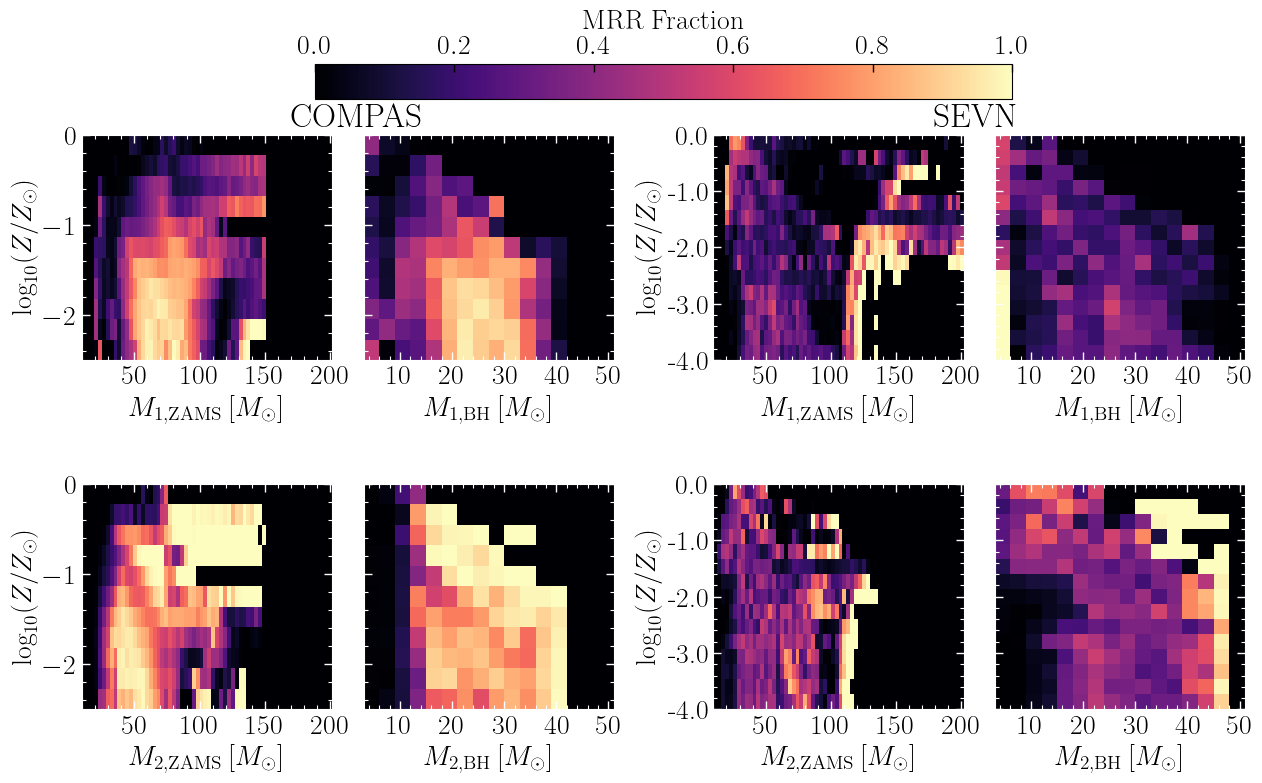

In [8]:
fig = plt.figure(figsize=(15, 15))
gs = gridspec.GridSpec(
    3, 5,
    width_ratios=[1, 1, 0.15, 1, 1],  # <-- middle gap
    wspace=0.15,
    hspace=0.55
)

axes = np.empty((2,4), dtype=object)

# Left block (COMPAS)
for i in range(2):
    axes[i,0] = fig.add_subplot(gs[i,0])
    axes[i,1] = fig.add_subplot(gs[i,1])

# Right block (SEVN)
for i in range(2):
    axes[i,2] = fig.add_subplot(gs[i,3])
    axes[i,3] = fig.add_subplot(gs[i,4])
    

cmap = "magma"
vmin, vmax = 0.0, 1.0

def pmesh(ax, xbins, zbins, data):
    return ax.pcolormesh(xbins, zbins, data,
                         cmap=cmap, vmin=vmin, vmax=vmax,
                         shading="auto", linewidth=0, edgecolors='face')

# --- Row 0: M1 ---
im00 = pmesh(axes[0, 0], M1z_bins,  Z_bins_COMPAS, map_C_M1z)
im01 = pmesh(axes[0, 1], BH1_bins,  Z_bins_COMPAS, map_C_M1bh)
im02 = pmesh(axes[0, 2], M1z_bins,  Z_bins_SEVN,   map_S_M1z)
im03 = pmesh(axes[0, 3], BH1_bins,  Z_bins_SEVN,   map_S_M1bh)

# --- Row 1: M2 ---
im10 = pmesh(axes[1, 0], M2z_bins,  Z_bins_COMPAS, map_C_M2z)
im11 = pmesh(axes[1, 1], BH2_bins,  Z_bins_COMPAS, map_C_M2bh)
im12 = pmesh(axes[1, 2], M2z_bins,  Z_bins_SEVN,   map_S_M2z)
im13 = pmesh(axes[1, 3], BH2_bins,  Z_bins_SEVN,   map_S_M2bh)


# Column titles (top row only)
axes[0, 0].set_title(r"COMPAS",x=1.1)#, fontsize=13)
axes[0, 1].set_title(r" ")
axes[0, 2].set_title(r"SEVN",x=1.05)
axes[0, 3].set_title(r" ")#,     fontsize=13)

# y-labels (left column only) 
axes[0, 0].set_ylabel(r"$\log_{10}(Z/Z_\odot)$")#, fontsize=12)
axes[1, 0].set_ylabel(r"$\log_{10}(Z/Z_\odot)$")#, fontsize=12)

axes[0, 2].set_ylabel(r"$\log_{10}(Z/Z_\odot)$")#, fontsize=12)
axes[1, 2].set_ylabel(r"$\log_{10}(Z/Z_\odot)$")#, fontsize=12)




axes[1, 0].set_xlabel(r"$M_{2,\mathrm{ZAMS}}\,[M_\odot]$")
axes[1, 1].set_xlabel(r"$M_{2,\mathrm{BH}}\,[M_\odot]$")
axes[1, 2].set_xlabel(r"$M_{2,\mathrm{ZAMS}}\,[M_\odot]$")
axes[1, 3].set_xlabel(r"$M_{2,\mathrm{BH}}\,[M_\odot]$")

axes[0, 0].set_xlabel(r"$M_{1,\mathrm{ZAMS}}\,[M_\odot]$")
axes[0, 1].set_xlabel(r"$M_{1,\mathrm{BH}}\,[M_\odot]$")
axes[0, 2].set_xlabel(r"$M_{1,\mathrm{ZAMS}}\,[M_\odot]$")
axes[0, 3].set_xlabel(r"$M_{1,\mathrm{BH}}\,[M_\odot]$")

for ax in axes[:, [1, 3]].ravel():
    ax.tick_params(labelleft=False)


for ax in axes[:, 2:].ravel():
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

# --- Rasterize + white ticks ---
all_ims = [im00, im01, im02, im03,
           im10, im11, im12, im13]

for im in all_ims:
    im.set_rasterized(True)

for ax in axes.ravel():
    ax.minorticks_on()
    ax.tick_params(which='both', color='white', labelcolor='k')
    for spine in ax.spines.values():
        spine.set_edgecolor('white')
    ax.xaxis.label.set_color('k')
    ax.yaxis.label.set_color('k')

for ax in axes[1, [0, 2]]:  # ZAMS 
    ax.set_xticks([50,100,150,200])  


for ax in axes[0, [0, 2]]:  # ZAMS 
    ax.set_xticks([50,100,150,200])  


for ax in axes[1, [0, 2]]:  # ZAMS 
    ax.set_xticks([50,100,150,200])  


for ax in axes[0, [1, 3]]:  # BH
    ax.set_xticks([10,20, 30,40, 50])  

for ax in axes[1, [1, 3]]:  # BH
    ax.set_xticks([10,20, 30,40, 50])  
    
# ------------------------------
# Shared colorbar
# ------------------------------
cbar = fig.colorbar(
    im13, ax=axes.ravel().tolist(),
    shrink=0.6, pad=0.05, location="top"
)
cbar.set_label("MRR Fraction")#, fontsize=14)

plt.tight_layout()
plt.savefig("../plots/final-mrr_3x4_compas_v_sevn_binarydefined.pdf", bbox_inches="tight", pad_inches=0.04)
plt.show()